# Lab Assignment 2 - Part A: Linear Regression
Please refer to the `README.pdf` for full laboratory instructions.

## Problem Statement
A dataset is included related to red and white vinho verde wine samples, from the north of Portugal. In this exercise, we look at a subset of the data and try to **predict wine's citric acid level based on other features**.

### Dataset Description
Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. **citric acid** (TARGET - what we want to predict)
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
12. quality (score between 0 and 10)

### Your Tasks
1. **Implement linear regression** from scratch using least-squares (you may use `np.linalg.lstsq()`)
2. Start with 'alcohol' and 'density' as features. **Find a 3rd feature** that improves prediction the most
3. **Find the 4th feature**. Analyze what happens with all features
4. **Provide plots** comparing predictions vs actual values

## Setup: Load the Dataset
The data is provided through `ucimlrepo`. Install and import required packages below.

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
# We take 100 samples and predict the citric acid number through various features
X = wine_quality.data.features[:100]
X = X.drop(columns=['citric_acid'])
y = wine_quality.data.features[:100]['citric_acid']
print(X.keys())

Index(['fixed_acidity', 'volatile_acidity', 'residual_sugar', 'chlorides',
       'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH',
       'sulphates', 'alcohol'],
      dtype='object')


### Write and Run Your Own Code

# 1.Define the linear regression

In [3]:
#Library declarations
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def linear_regression(X, y):
    X = np.c_[np.ones(X.shape[0]), X]  # add bias term
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def predict(X, beta):
    X = np.c_[np.ones(X.shape[0]), X]
    return X @ beta

def mse(y, yhat):
    return np.mean((y - yhat)**2)


# 2: Baseline model (Alcohol + Density)

In [6]:
base_features = ['alcohol', 'density']

X_base = X[base_features].values
y_vals = y.values

beta_base = linear_regression(X_base, y_vals)
yhat_base = predict(X_base, beta_base)

print("Baseline MSE:", mse(y_vals, yhat_base))


Baseline MSE: 0.02841200722745913


# 3: Find the best 3rd featurex

In [7]:
candidate_features = [
    'fixed_acidity',
    'volatile_acidity',
    'residual_sugar',
    'pH',
    'sulphates',
    'chlorides'
]

results = {}

for f in candidate_features:
    X_tmp = X[base_features + [f]].values
    beta = linear_regression(X_tmp, y_vals)
    yhat = predict(X_tmp, beta)
    results[f] = mse(y_vals, yhat)

results

best_3rd = min(results, key=results.get)
print("Best 3rd feature:", best_3rd)


Best 3rd feature: volatile_acidity


In [30]:
# Remaining candidates after choosing best_3rd
remaining_features = [
    'fixed_acidity',
    'volatile_acidity',
    'residual_sugar',
    'pH',
    'sulphates',
    'chlorides'
]

remaining_features.remove(best_3rd)

fourth_results = {}

for f in remaining_features:
    X_tmp = X[['alcohol', 'density', best_3rd, f]].values
    beta = linear_regression(X_tmp, y_vals)
    yhat = predict(X_tmp, beta)
    fourth_results[f] = mse(y_vals, yhat)

fourth_results
best_4th = min(fourth_results, key=fourth_results.get)
best_4th


'fixed_acidity'

In [31]:
fourth_results

{'fixed_acidity': np.float64(0.01541537298259697),
 'residual_sugar': np.float64(0.016780000981565783),
 'pH': np.float64(0.016453277391077287),
 'sulphates': np.float64(0.016625107918714115),
 'chlorides': np.float64(0.015833592421808415)}

# 5: Visualization
Create plots comparing model predictions vs actual values for different feature combinations.


In [24]:
def plot_predictions(y, yhat, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y, yhat, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Actual Citric Acid")
    plt.ylabel("Predicted Citric Acid")
    plt.title(title)
    plt.grid(True)
    plt.show()


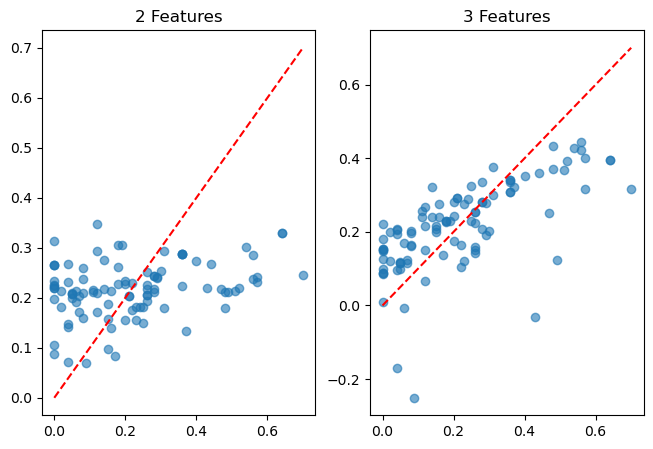

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.scatter(y_vals, yhat2, alpha=0.6)
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--')
plt.title("2 Features")

plt.subplot(1,3,2)
plt.scatter(y_vals, yhat3, alpha=0.6)
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--')
plt.title("3 Features")

plt.show()


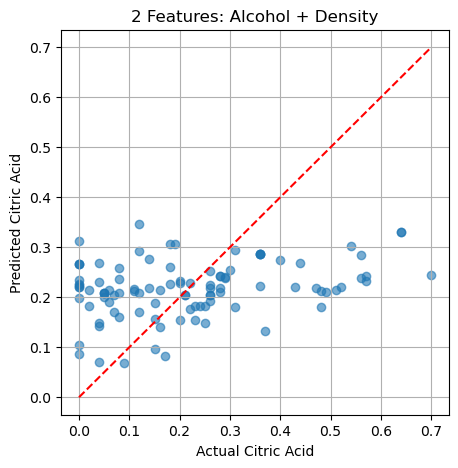

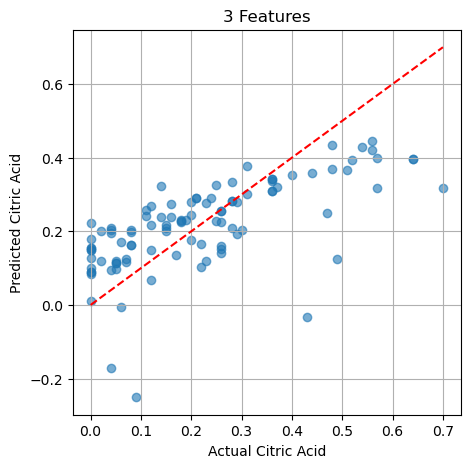

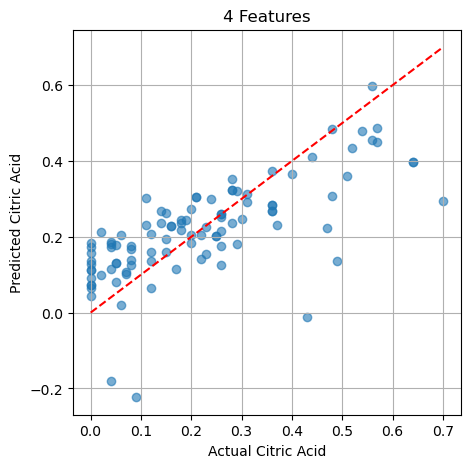

In [26]:
X2 = X[['alcohol', 'density']].values
beta2 = linear_regression(X2, y_vals)
yhat2 = predict(X2, beta2)

plot_predictions(y_vals, yhat2, "2 Features: Alcohol + Density")

X3 = X[['alcohol', 'density', best_3rd]].values
beta3 = linear_regression(X3, y_vals)
yhat3 = predict(X3, beta3)

plot_predictions(y_vals, yhat3, "3 Features")

X4 = X[['alcohol', 'density', best_3rd, best_4th]].values
beta4 = linear_regression(X4, y_vals)
yhat4 = predict(X4, beta4)

plot_predictions(y_vals, yhat4, "4 Features")

## Summary and Discussion

### Results Table
| Model | Features | Error |
|-------|----------|-------|
| Model 1 | alcohol, density | ? |
| Model 2 | alcohol, density, ? | ? |
| Model 3 | alcohol, density, ?, ? | ? |
| Full Model | all features | ? |

### Discussion
*Write your analysis here:*
- Which features are most important for predicting citric acid?
- Does adding more features always improve the model?
- What did you learn from this exercise?


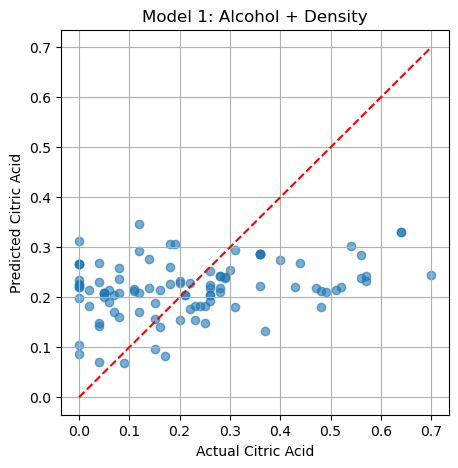

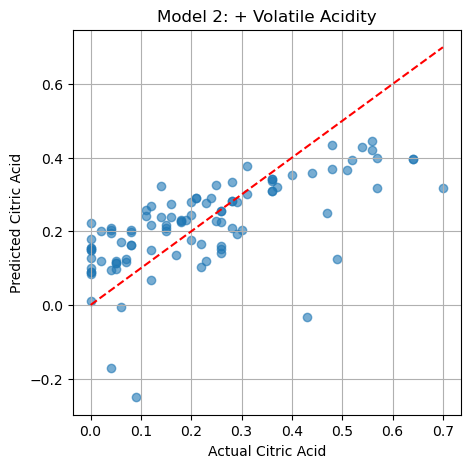

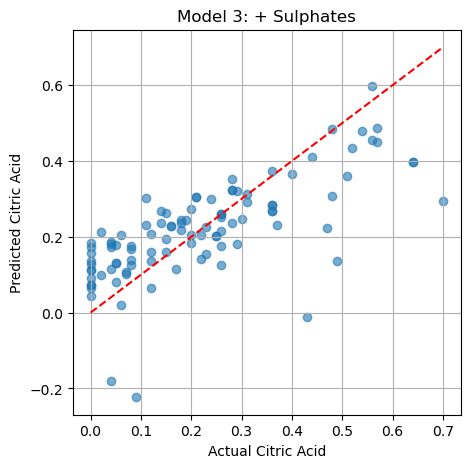

In [32]:
plot_predictions(y_vals, yhat2, "Model 1: Alcohol + Density")
plot_predictions(y_vals, yhat3, "Model 2: + Volatile Acidity")
plot_predictions(y_vals, yhat4, "Model 3: + Sulphates")
